In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the California Housing dataset
housing = fetch_california_housing()

# Convert to pandas DataFrame
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Display first few rows
print("First 5 rows of dataset:")
print(X.head())

# Dataset information
print("\nDataset shape:", X.shape)
print("Number of features:", X.shape[1])

First 5 rows of dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Dataset shape: (20640, 8)
Number of features: 8


In [3]:
# Basic statistical summary
print(X.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.429741     33.930000   -1

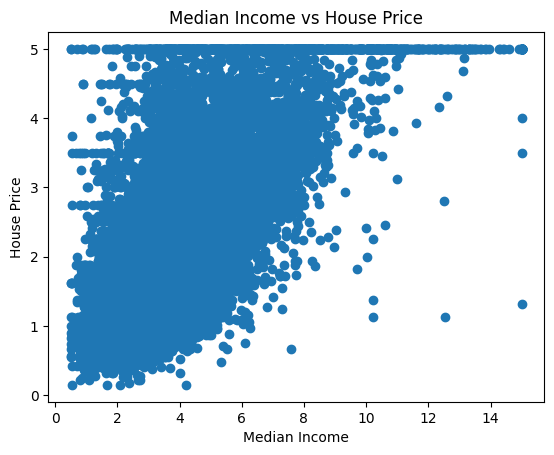

In [4]:
plt.figure()

plt.scatter(X["MedInc"], y)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")

plt.show()

In [5]:
# Split data into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [6]:
# Standardization helps models perform better
# especially when features have different scales

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [8]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Feature Importance (Linear Regression Coefficients):")
print(coefficients.sort_values(by="Coefficient", ascending=False))

Feature Importance (Linear Regression Coefficients):
      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829
2    AveRooms    -0.294410
7   Longitude    -0.869842
6    Latitude    -0.896929


In [9]:
# Predict house prices

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [10]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Mean Squared Error:", train_mse)
print("Testing Mean Squared Error:", test_mse)

print("\nTraining R² Score:", train_r2)
print("Testing R² Score:", test_r2)

Training Mean Squared Error: 0.5179331255246699
Testing Mean Squared Error: 0.5558915986952444

Training R² Score: 0.6125511913966952
Testing R² Score: 0.5757877060324508


In [11]:
print("Overfitting Check")

if train_mse < test_mse:
    print("Model may have slight overfitting.")
else:
    print("Model generalizes well.")

Overfitting Check
Model may have slight overfitting.


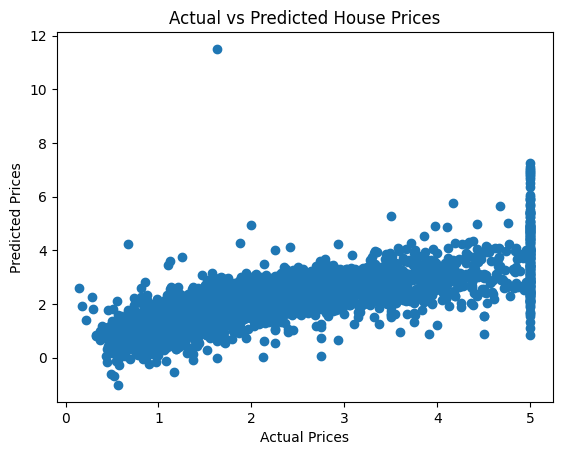

In [12]:
plt.figure()

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

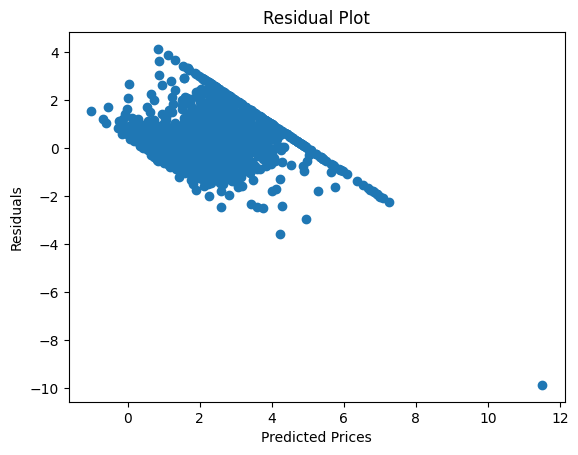

In [13]:
residuals = y_test - y_test_pred

plt.figure()

plt.scatter(y_test_pred, residuals)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

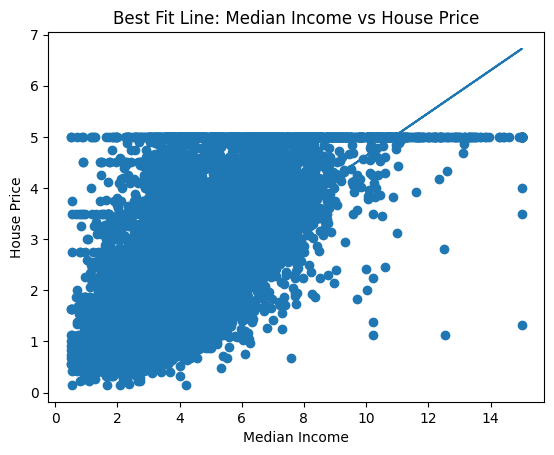

In [15]:
# Select one feature for visualization
X_feature = X["MedInc"].values.reshape(-1, 1)
y_target = y

# Train a simple linear regression on this single feature
from sklearn.linear_model import LinearRegression

line_model = LinearRegression()
line_model.fit(X_feature, y_target)

# Predictions for the best fit line
y_line = line_model.predict(X_feature)

# Plot data points
plt.figure()

plt.scatter(X_feature, y_target)

# Plot regression line
plt.plot(X_feature, y_line)

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Best Fit Line: Median Income vs House Price")

plt.show()

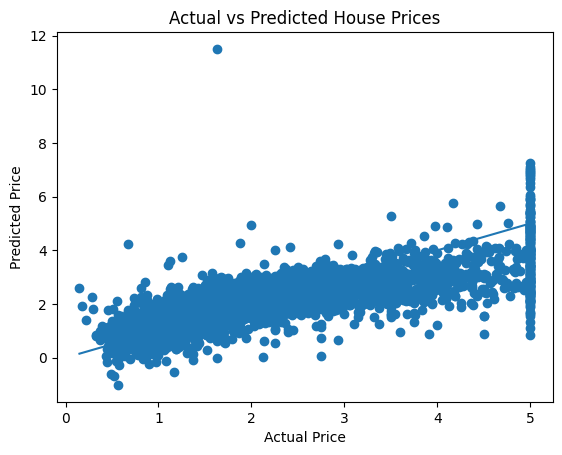

In [16]:
plt.figure()

plt.scatter(y_test, y_test_pred)

# perfect prediction reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()